In [2]:
import numpy as np
import pandas as pd
import pickle
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.metrics import root_mean_squared_error

import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

with open('processed/concrete.pkl', 'rb') as f:
    data = pickle.load(f)

FEATURE_NAMES = ['Cement', 'Slag', 'FlyAsh', 'Water',
                 'Superplast', 'CoarseAgg', 'FineAgg', 'Age']

X_train = data['X_train']
X_val   = data['X_val']
X_test  = data['X_test']
y_train = data['y_train']
y_val   = data['y_val']
y_test  = data['y_test']
n_features = X_train.shape[1]

print(f"Concrete Compressive Strength — n_train={len(X_train)}, n_test={len(X_test)}, d={n_features}")
print(f"Feature names: {FEATURE_NAMES}")

with open('models/xrfm_concrete.pkl', 'rb') as f:
    xrfm_model = pickle.load(f)

print(f"\nLoaded trained xRFM model.")

Concrete Compressive Strength — n_train=659, n_test=206, d=8
Feature names: ['Cement', 'Slag', 'FlyAsh', 'Water', 'Superplast', 'CoarseAgg', 'FineAgg', 'Age']

Loaded trained xRFM model.


In [5]:
def collect_agop_diagonals(xrfm_obj, feature_dim):
    """Walk the xRFM tree, collect AGOP (M matrix) diagonals from every leaf.

    Returns:
        leaf_diags: list of 1D arrays, one per leaf (AGOP diagonal)
        leaf_sizes: list of ints, training-sample count per leaf
    """
    leaf_diags = []
    leaf_sizes = []

    def walk(node):
        if node is None:
            return
        if node.get('type') == 'leaf':
            rfm = node.get('model')
            M = getattr(rfm, 'M', None)
            if M is None:
                M = getattr(rfm, 'sqrtM', None)
                if M is not None:
                    M = M @ M.T
            if M is not None:
                M_np = M.detach().cpu().numpy() if isinstance(M, torch.Tensor) else np.asarray(M)
                if M_np.ndim == 2:
                    diag = np.diag(M_np)
                else:
                    diag = M_np
                leaf_diags.append(diag)
                idx = node.get('train_indices', None)
                if idx is not None:
                    try:
                        leaf_sizes.append(len(idx))
                    except Exception:
                        leaf_sizes.append(0)
                else:
                    leaf_sizes.append(0)
        else:
            walk(node.get('left'))
            walk(node.get('right'))

    for tree in getattr(xrfm_obj, 'trees', []):
        walk(tree)

    return leaf_diags, leaf_sizes


leaf_diags, leaf_sizes = collect_agop_diagonals(xrfm_model, n_features)
print(f"Number of leaves: {len(leaf_diags)}")
print(f"Leaf sizes (n_train per leaf): {leaf_sizes}")

if len(leaf_diags) == 0:
    raise RuntimeError("No AGOP diagonals extracted — model may lack M matrices.")

diag_matrix = np.vstack(leaf_diags)
print(f"\nAGOP diagonal matrix shape: {diag_matrix.shape}  (leaves × features)")

if sum(leaf_sizes) > 0:
    weights = np.array(leaf_sizes, dtype=float) / sum(leaf_sizes)
    agop_diag_mean = (diag_matrix.T @ weights)
    print("AGOP diagonal aggregated as sample-weighted average across leaves.")
else:
    agop_diag_mean = diag_matrix.mean(axis=0)
    print("AGOP diagonal aggregated as simple mean across leaves.")

if agop_diag_mean.max() > 0:
    agop_diag_mean_norm = agop_diag_mean / agop_diag_mean.max()
else:
    agop_diag_mean_norm = agop_diag_mean

print(f"\nAGOP diagonal (mean across leaves, normalised):")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  {name:12s}: {agop_diag_mean_norm[i]:.4f}")

Number of leaves: 1
Leaf sizes (n_train per leaf): [659]

AGOP diagonal matrix shape: (1, 8)  (leaves × features)
AGOP diagonal aggregated as sample-weighted average across leaves.

AGOP diagonal (mean across leaves, normalised):
  Cement      : 0.6089
  Slag        : 0.2137
  FlyAsh      : 0.6444
  Water       : 0.3141
  Superplast  : 0.0891
  CoarseAgg   : 0.2461
  FineAgg     : 0.0343
  Age         : 1.0000


In [6]:
pca = PCA(n_components=n_features, random_state=RANDOM_SEED)
pca.fit(X_train)

explained = pca.explained_variance_ratio_
components = pca.components_

pca_scores = np.abs(components).T @ explained
pca_scores_norm = pca_scores / pca_scores.max()

print("PCA loadings (variance-weighted, normalised):")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  {name:12s}: {pca_scores_norm[i]:.4f}")

PCA loadings (variance-weighted, normalised):
  Cement      : 0.8635
  Slag        : 0.8583
  FlyAsh      : 0.9563
  Water       : 1.0000
  Superplast  : 0.9917
  CoarseAgg   : 0.9505
  FineAgg     : 0.8228
  Age         : 0.9354


In [7]:
mi_scores = mutual_info_regression(X_train, y_train, random_state=RANDOM_SEED)
mi_scores_norm = mi_scores / mi_scores.max()

print("Mutual Information with target (normalised):")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  {name:12s}: {mi_scores_norm[i]:.4f}")

Mutual Information with target (normalised):
  Cement      : 0.7645
  Slag        : 0.5489
  FlyAsh      : 0.2336
  Water       : 0.8438
  Superplast  : 0.5440
  CoarseAgg   : 0.5265
  FineAgg     : 0.4237
  Age         : 1.0000


In [8]:
with open('models/xgb_concrete.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

perm_result = permutation_importance(
    xgb_model, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_SEED,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
)

perm_scores = perm_result.importances_mean
perm_scores_norm = perm_scores / perm_scores.max() if perm_scores.max() > 0 else perm_scores

print("\nPermutation Importance on XGBoost test set (normalised):")
for i, name in enumerate(FEATURE_NAMES):
    print(f"  {name:12s}: {perm_scores_norm[i]:.4f}")


Permutation Importance on XGBoost test set (normalised):
  Cement      : 0.6519
  Slag        : 0.2796
  FlyAsh      : 0.0249
  Water       : 0.4706
  Superplast  : 0.2202
  CoarseAgg   : 0.0261
  FineAgg     : 0.1122
  Age         : 1.0000


In [9]:
comparison_df = pd.DataFrame({
    'Feature': FEATURE_NAMES,
    'AGOP_diag': agop_diag_mean_norm,
    'PCA_loadings': pca_scores_norm,
    'Mutual_Info': mi_scores_norm,
    'Permutation_Imp': perm_scores_norm,
})

for col in ['AGOP_diag', 'PCA_loadings', 'Mutual_Info', 'Permutation_Imp']:
    comparison_df[f'{col}_rank'] = comparison_df[col].rank(ascending=False, method='min').astype(int)

comparison_df.to_csv('results/tables/interpretability_comparison.csv', index=False)

print("Feature importance comparison (normalised scores):")
print("=" * 95)
print(comparison_df[['Feature', 'AGOP_diag', 'PCA_loadings', 'Mutual_Info', 'Permutation_Imp']].round(4).to_string(index=False))
print()
print("=" * 95)
print("Feature rankings (1 = most important):")
print("=" * 95)
rank_cols = ['Feature', 'AGOP_diag_rank', 'PCA_loadings_rank', 'Mutual_Info_rank', 'Permutation_Imp_rank']
print(comparison_df[rank_cols].to_string(index=False))

Feature importance comparison (normalised scores):
   Feature  AGOP_diag  PCA_loadings  Mutual_Info  Permutation_Imp
    Cement     0.6089        0.8635       0.7645           0.6519
      Slag     0.2137        0.8583       0.5489           0.2796
    FlyAsh     0.6444        0.9563       0.2336           0.0249
     Water     0.3141        1.0000       0.8438           0.4706
Superplast     0.0891        0.9917       0.5440           0.2202
 CoarseAgg     0.2461        0.9505       0.5265           0.0261
   FineAgg     0.0343        0.8228       0.4237           0.1122
       Age     1.0000        0.9354       1.0000           1.0000

Feature rankings (1 = most important):
   Feature  AGOP_diag_rank  PCA_loadings_rank  Mutual_Info_rank  Permutation_Imp_rank
    Cement               3                  6                 3                     2
      Slag               6                  7                 4                     4
    FlyAsh               2                  3            

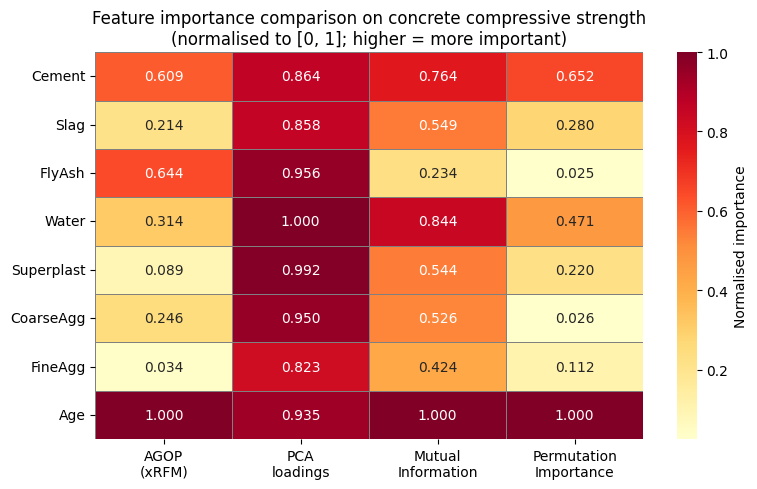

Saved: results/figures/interpretability_heatmap.png


In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

heatmap_data = comparison_df[['AGOP_diag', 'PCA_loadings', 'Mutual_Info', 'Permutation_Imp']].values
heatmap_df = pd.DataFrame(
    heatmap_data,
    index=FEATURE_NAMES,
    columns=['AGOP\n(xRFM)', 'PCA\nloadings', 'Mutual\nInformation', 'Permutation\nImportance'],
)

sns.heatmap(
    heatmap_df, annot=True, fmt='.3f', cmap='YlOrRd',
    cbar_kws={'label': 'Normalised importance'}, ax=ax,
    linewidths=0.5, linecolor='gray',
)
ax.set_title('Feature importance comparison on concrete compressive strength\n(normalised to [0, 1]; higher = more important)',
             fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')

plt.tight_layout()
plt.savefig('results/figures/interpretability_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/interpretability_heatmap.png")

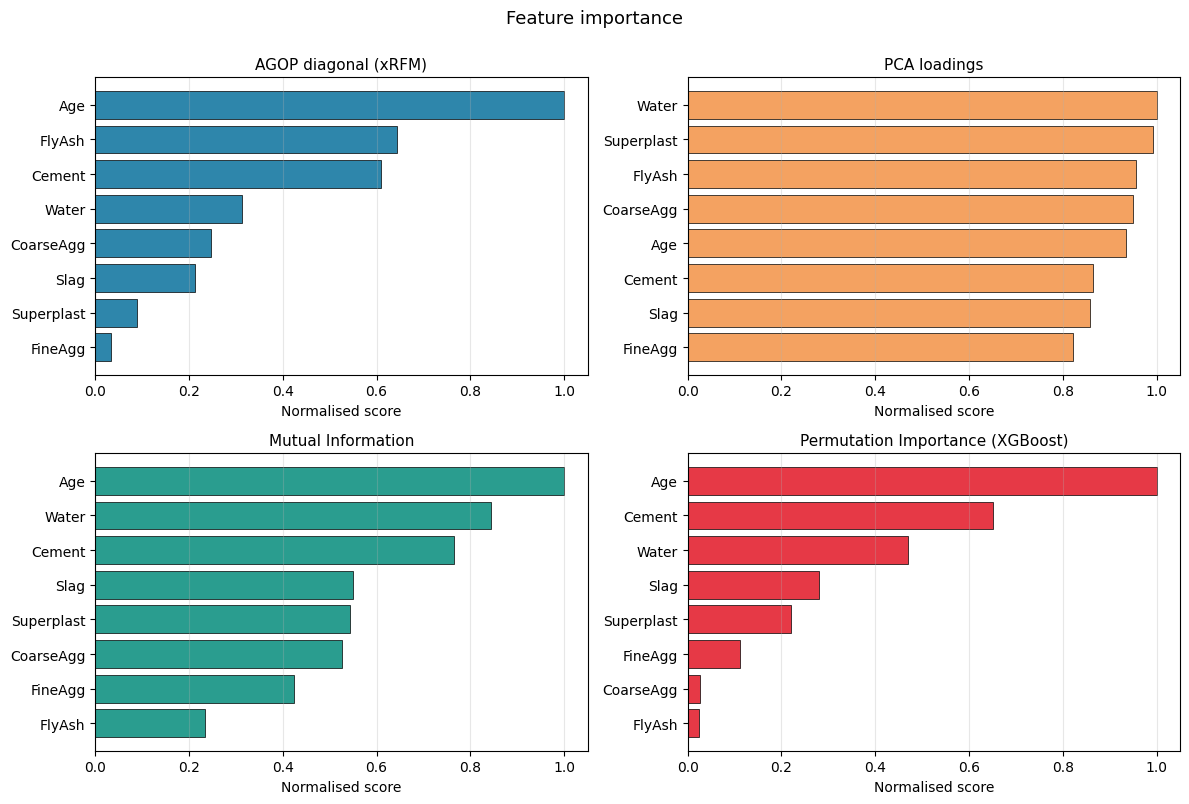

Saved: results/figures/interpretability_bars.png


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
methods = [
    ('AGOP_diag', 'AGOP diagonal (xRFM)', '#2E86AB'),
    ('PCA_loadings', 'PCA loadings', '#F4A261'),
    ('Mutual_Info', 'Mutual Information', '#2A9D8F'),
    ('Permutation_Imp', 'Permutation Importance (XGBoost)', '#E63946'),
]

for ax, (col, title, color) in zip(axes.flatten(), methods):
    sorted_idx = comparison_df[col].argsort()[::-1]
    sorted_df = comparison_df.iloc[sorted_idx]
    ax.barh(sorted_df['Feature'], sorted_df[col], color=color, edgecolor='black', linewidth=0.5)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=11)
    ax.set_xlim(0, 1.05)
    ax.set_xlabel('Normalised score')
    ax.grid(True, axis='x', alpha=0.3)

fig.suptitle('Feature importance',
             fontsize=13, y=1.00)
plt.tight_layout()
plt.savefig('results/figures/interpretability_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/interpretability_bars.png")

Spearman rank correlation between methods:
              AGOP    PCA     MI  Permutation
AGOP         1.000  0.262  0.405        0.357
PCA          0.262  1.000  0.119       -0.095
MI           0.405  0.119  1.000        0.952
Permutation  0.357 -0.095  0.952        1.000

Interpretation:
  1.0  = identical ranking
  0.0  = unrelated rankings
 -1.0  = exactly reversed rankings

Saved: results/tables/interpretability_correlations.csv


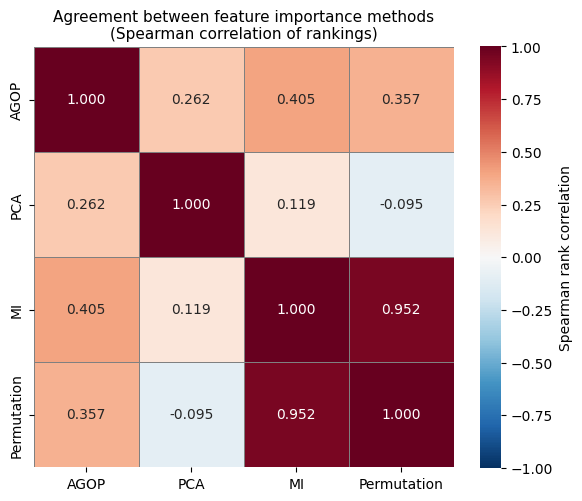

Saved: results/figures/interpretability_correlation.png


In [13]:
from scipy.stats import spearmanr

score_cols = ['AGOP_diag', 'PCA_loadings', 'Mutual_Info', 'Permutation_Imp']
n = len(score_cols)
corr_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        rho, _ = spearmanr(comparison_df[score_cols[i]], comparison_df[score_cols[j]])
        corr_matrix[i, j] = rho

corr_df = pd.DataFrame(
    corr_matrix,
    index=['AGOP', 'PCA', 'MI', 'Permutation'],
    columns=['AGOP', 'PCA', 'MI', 'Permutation'],
)

print("Spearman rank correlation between methods:")
print("=" * 60)
print(corr_df.round(3).to_string())
print()
print("Interpretation:")
print("  1.0  = identical ranking")
print("  0.0  = unrelated rankings")
print(" -1.0  = exactly reversed rankings")

corr_df.to_csv('results/tables/interpretability_correlations.csv')
print("\nSaved: results/tables/interpretability_correlations.csv")

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_df, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            cbar_kws={'label': 'Spearman rank correlation'}, ax=ax,
            linewidths=0.5, linecolor='gray')
ax.set_title('Agreement between feature importance methods\n(Spearman correlation of rankings)', fontsize=11)
plt.tight_layout()
plt.savefig('results/figures/interpretability_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/figures/interpretability_correlation.png")